 =============================================================
  ##               TRABAJO FINAL INTEGRADOR       
  
  ###                VISIÓN POR COMPUTADORA II
  ###             Chest CT-Scan images Dataset 2025
 =============================================================


**ALUMNOS:**
- Mauro Fabian Barquinero
- Juan Cruz Ojeda
- Mariano Campos
- Jose Luis Perez Galindo

---

[DATASET](https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images)

### IMPORT

In [5]:
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import seaborn as sns
import shutil

from collections import defaultdict
from PIL import Image
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
from pathlib import Path

import imagehash

---

### ANALISIS DE LA ESTRUCTURA DEL DATASET

### Verificando las carpetas del dataset

In [28]:
# Path del directorio
data_dir = os.path.join(".", "Data")

# Verificamos que el directorio exista
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"No se encontró el directorio: {data_dir}")

# Listar las clases dentro de cada subconjunto: train, test y valid
subsets = ['train', 'test', 'valid']

for subset in subsets:
    subset_path = os.path.join(data_dir, subset)
    if not os.path.exists(subset_path):
        print(f"[ADVERTENCIA] No se encontró el subdirectorio: {subset_path}")
        continue
    classes = os.listdir(subset_path)
    print(f"\n{subset.upper()}:")
    for cls in classes:
        print(f"  - {cls}")


TRAIN:
  - adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
  - large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa
  - normal
  - squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa

TEST:
  - adenocarcinoma
  - large.cell.carcinoma
  - normal
  - squamous.cell.carcinoma

VALID:
  - adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib
  - large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa
  - normal
  - squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa


### Como podemos visualizar, los nombres por subtipo de cáncer varian. Se debería estandarizar los nombres.

 #### Se procede a visualizar las imágenes por clases.


📂 train/adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib:


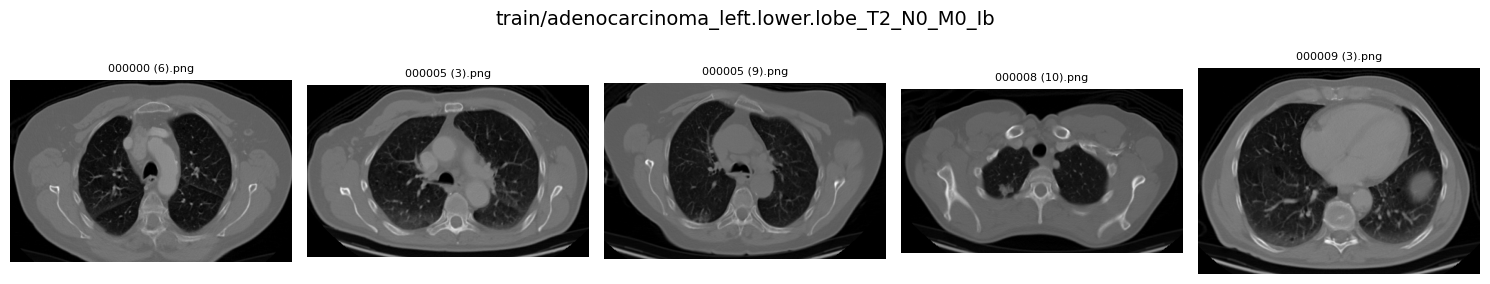


📂 train/large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa:


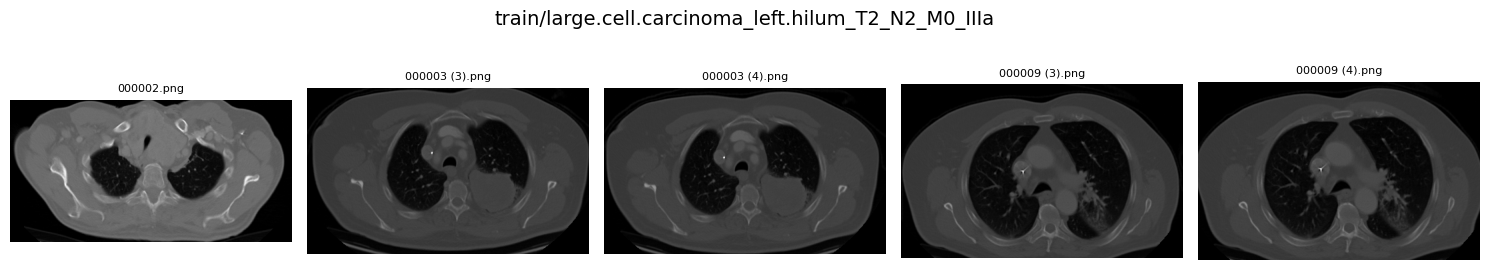


📂 train/normal:


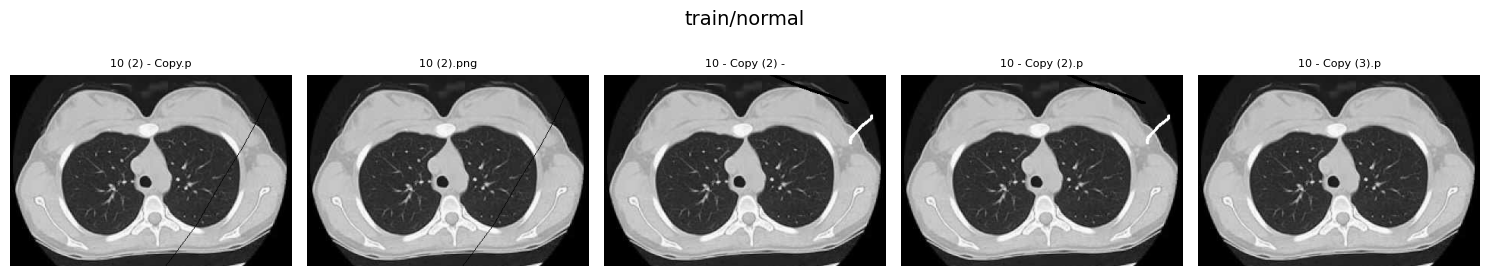


📂 train/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa:


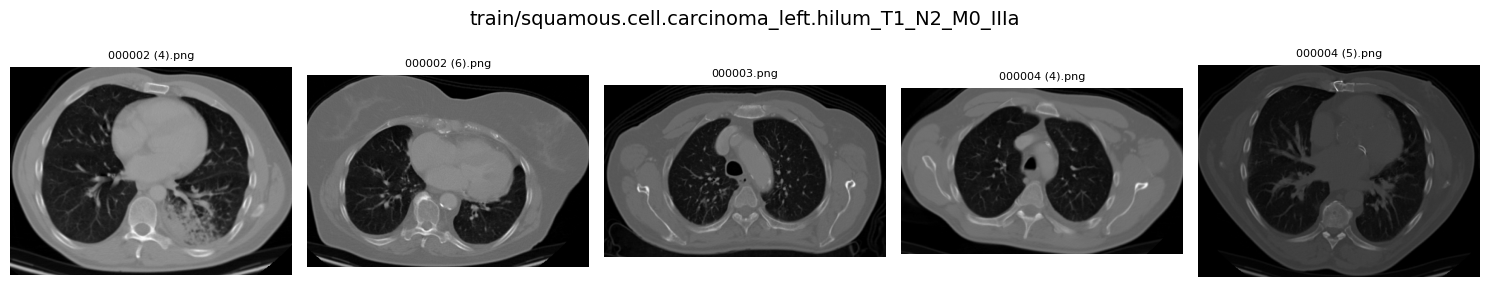


📂 valid/adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib:


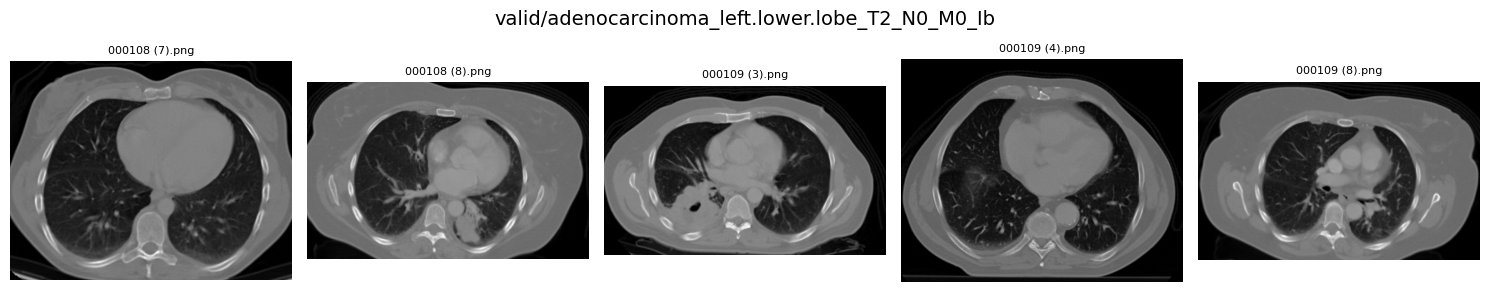


📂 valid/large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa:


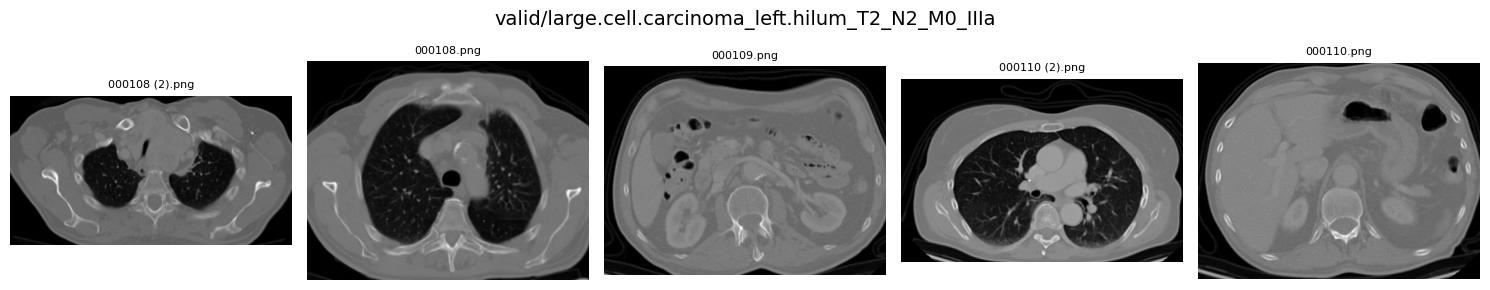


📂 valid/normal:


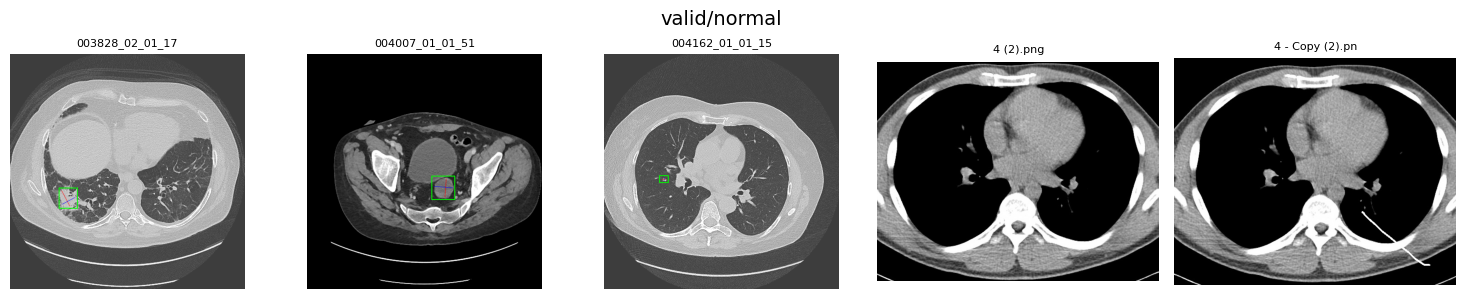


📂 valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa:


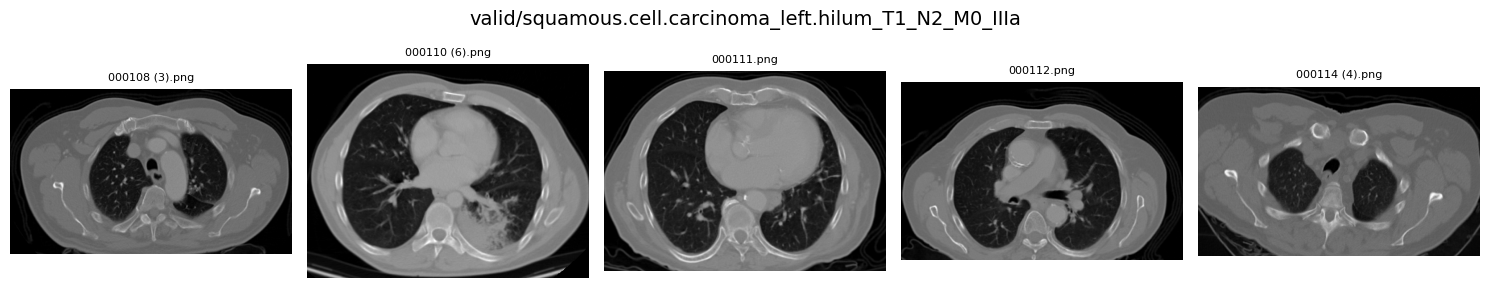


📂 test/adenocarcinoma:


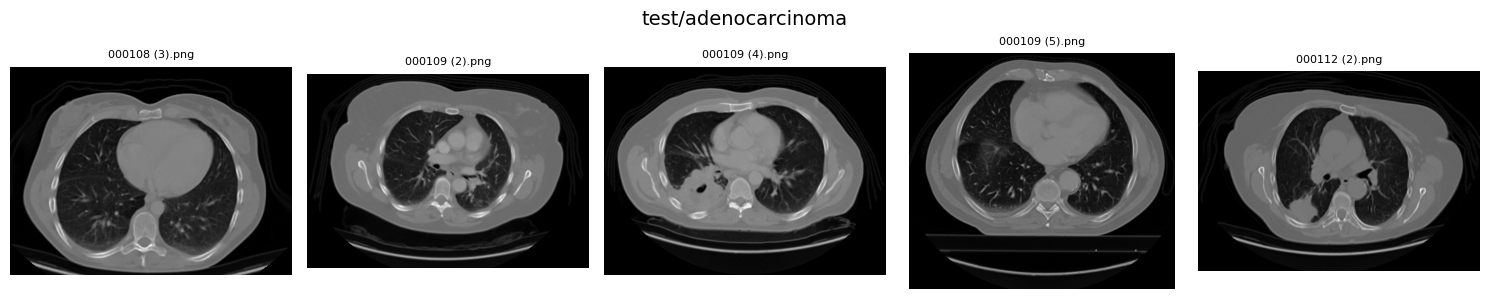


📂 test/large.cell.carcinoma:


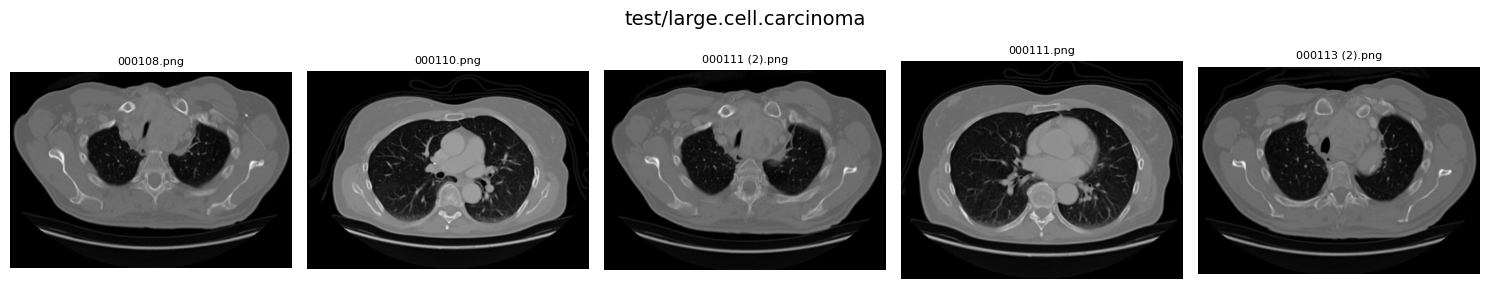


📂 test/normal:


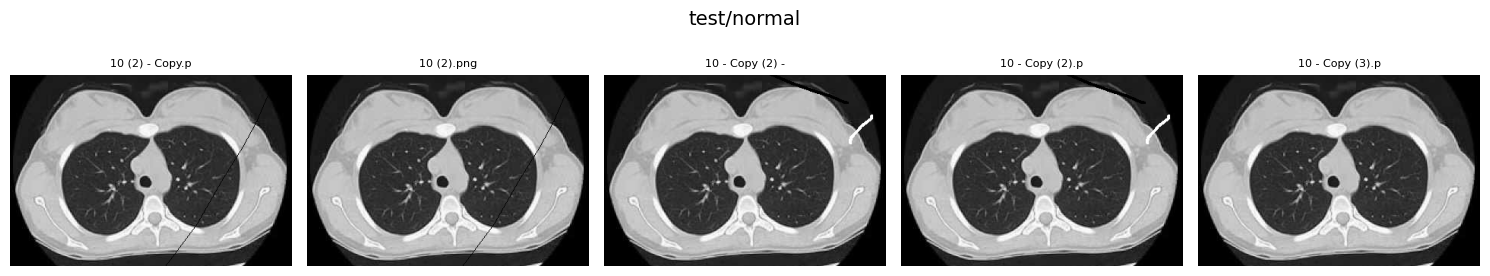


📂 test/squamous.cell.carcinoma:


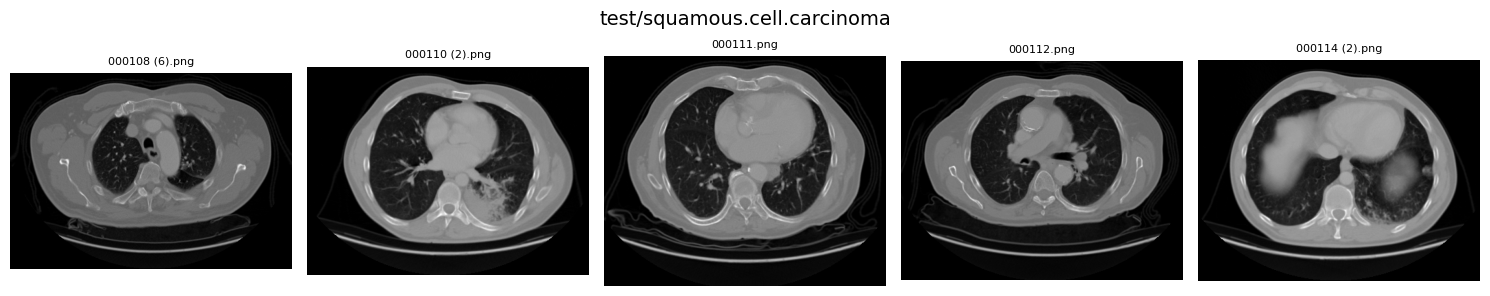

In [29]:
dataset_root = Path("./Data")

# Función para mostrar imágenes por subcarpeta sin importar el label
def mostrar_5_imagenes_por_subcarpeta(data_dir, subsets=["train", "valid", "test"]):
    for subset in subsets:
        subset_path = Path(data_dir) / subset
        if not subset_path.exists():
            print(f"[ADVERTENCIA] No existe el directorio {subset_path}")
            continue

        subfolders = [f for f in subset_path.iterdir() if f.is_dir()]
        for subfolder in subfolders:
            image_files = sorted([f for f in subfolder.iterdir() if f.is_file()])[:5]
            if not image_files:
                continue

            print(f"\n📂 {subset}/{subfolder.name}:")
            fig, axes = plt.subplots(1, len(image_files), figsize=(3 * len(image_files), 3))
            fig.suptitle(f"{subset}/{subfolder.name}", fontsize=14)

            if len(image_files) == 1:
                axes = [axes]

            for i, img_path in enumerate(image_files):
                img = cv2.imread(str(img_path))
                if img is None:
                    axes[i].axis("off")
                    axes[i].set_title("Error de lectura", fontsize=8)
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[i].imshow(img)
                axes[i].axis("off")
                axes[i].set_title(img_path.name[:15], fontsize=8)

            plt.tight_layout()
            plt.show()

# Ejecutar la función
mostrar_5_imagenes_por_subcarpeta(dataset_root)

### Podemos visualizar que algunas imágenes de la carpeta `valid` estan en RGB.

#### Procedemos a verificar si hay duplicados.

#### Conclusión sobre duplicados y similitud de imágenes

Se realizó una inspección sobre las imágenes del dataset y se pudo constatar que, en el caso de los distintos tipos de cáncer, no existen duplicados. Las imágenes que comparten el mismo identificador numérico corresponden al mismo estudio torácico, pero capturado desde diferentes cortes o ángulos. Esta diversidad de vistas permite una mejor visualización y análisis de la enfermedad desde distintas perspectivas.

Justificación de la conservación de imágenes similares
Se realizó una inspección visual del dataset y se comprobó que, en el caso de las clases con distintos tipos de cáncer, no hay imágenes duplicadas reales. Aquellas que comparten el mismo número base corresponden a cortes diferentes del mismo estudio torácico, permitiendo observar la enfermedad desde múltiples ángulos.

Durante el análisis también se detectaron imágenes con nombres similares (como aquellas que contienen copy o (2)), especialmente en la clase normal. Aunque algunas pueden parecer duplicadas, presentan pequeñas diferencias como anotaciones, marcas o variaciones de contraste. Estas diferencias enriquecen el conjunto de datos con ejemplos más realistas, por lo que se decidió conservar todas las imágenes.

A continuación se presentan dos ejemplos representativos de esta situación.

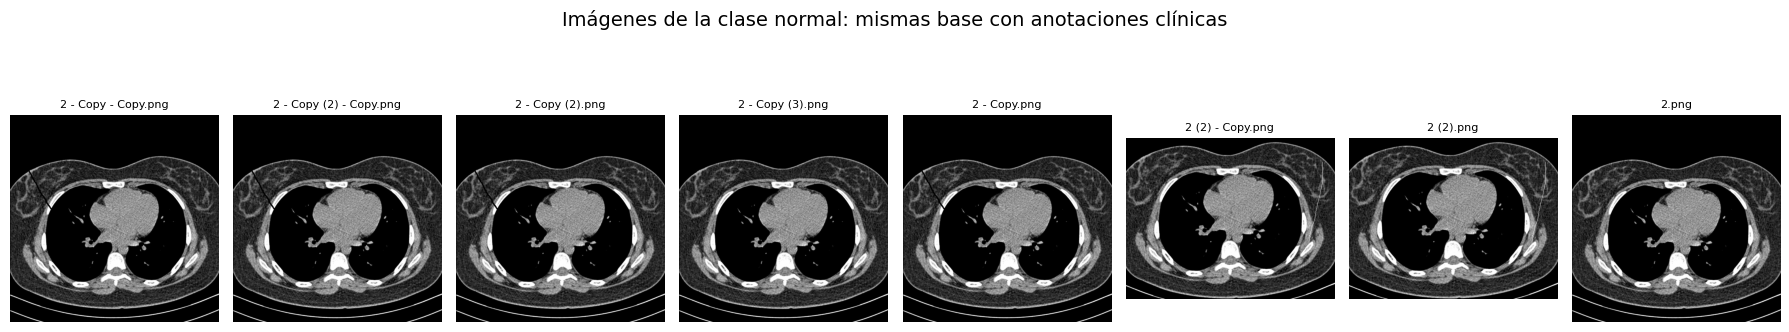

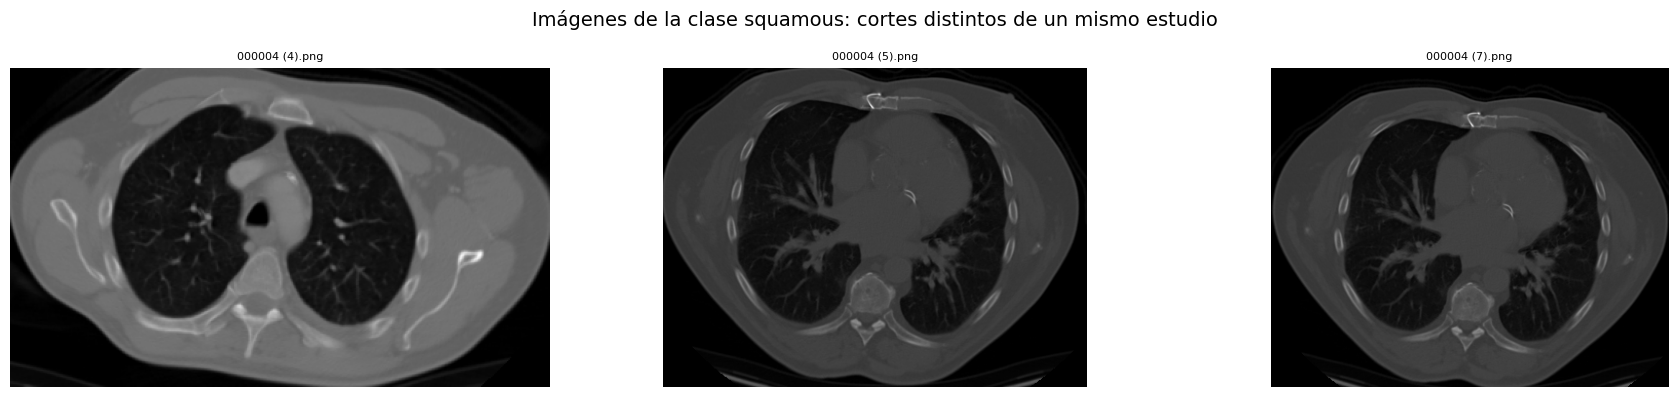

In [42]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

def mostrar_imagenes_por_nombres(ruta_clase, nombres_archivos, titulo_fila):
    fig, axes = plt.subplots(1, len(nombres_archivos), figsize=(18, 4))
    fig.suptitle(titulo_fila, fontsize=14)

    for ax, nombre in zip(axes, nombres_archivos):
        ruta_img = Path(ruta_clase) / nombre
        with Image.open(ruta_img) as img:
            ax.imshow(img, cmap='gray')
            ax.set_title(nombre, fontsize=8)
            ax.axis("off")
    plt.tight_layout()
    plt.show()

# Carpeta base
base_path = "Data/train"

# Imágenes de la clase 'normal'
imagenes_normal = [
    "2 - Copy - Copy.png",
    "2 - Copy (2) - Copy.png",
    "2 - Copy (2).png",
    "2 - Copy (3).png",
    "2 - Copy.png",
    "2 (2) - Copy.png",
    "2 (2).png",
    "2.png"
]
mostrar_imagenes_por_nombres(
    ruta_clase=f"{base_path}/normal",
    nombres_archivos=imagenes_normal,
    titulo_fila="Imágenes de la clase normal: mismas base con anotaciones clínicas"
)

# Imágenes de la clase 'squamous'
imagenes_squamous = [
    "000004 (4).png",
    "000004 (5).png",
    "000004 (7).png"
]
mostrar_imagenes_por_nombres(
    ruta_clase=f"{base_path}/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa",
    nombres_archivos=imagenes_squamous,
    titulo_fila="Imágenes de la clase squamous: cortes distintos de un mismo estudio"
)


#### Procedemos a verificar los tamaños de las imágenes del dataset.

In [44]:
splits = ["train", "valid", "test"]
labels = ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']


def obtener_dimensiones_imagenes(dataset_root, splits, labels, max_imgs=4):
    dimensiones = []

    for split in splits:
        for label in labels:
            folder = dataset_root / split / label
            if not folder.exists():
                continue
            image_files = sorted([f for f in folder.iterdir() if f.is_file()])[:max_imgs]
            for img_path in image_files:
                img = cv2.imread(str(img_path))
                if img is not None:
                    dimensiones.append((split, label, img.shape[0], img.shape[1]))  # alto, ancho

    return dimensiones

# Obtener dimensiones
dims = obtener_dimensiones_imagenes(dataset_root, splits, labels)

# 1. Convertir la lista a DataFrame
df_dims = pd.DataFrame(dims, columns=["split", "label", "height", "width"])

# 2. Agrupar y ocultar el contador (sin eliminar filas)
df_dims_grouped = df_dims.groupby(["split", "label", "height", "width"]).size().reset_index()

# 3. Ocultar la columna del contador (la última)
df_dims_grouped = df_dims_grouped.iloc[:, :-1]

# 4. Mostrar
df_dims_grouped

,split,label,height,width
0,test,adenocarcinoma,282,381
1,test,adenocarcinoma,335,486
2,test,adenocarcinoma,357,483
3,test,adenocarcinoma,406,456
4,test,large.cell.carcinoma,285,411
5,test,large.cell.carcinoma,296,417
6,test,large.cell.carcinoma,305,395
7,test,large.cell.carcinoma,308,438
8,test,normal,251,371
9,test,squamous.cell.carcinoma,314,425


### Podemos observar que las imágenes tienen diferentes tamaños. Ahora se procede a analizar si las clases estan desvalanceadas

In [45]:
# Ruta relativa a la carpeta Data
data_dir = os.path.join(".", "Data")
subsets = ['train', 'test', 'valid']

# Contador de imágenes por clase
image_counts = defaultdict(dict)

for subset in subsets:
    subset_path = os.path.join(data_dir, subset)
    if not os.path.exists(subset_path):
        continue
    for class_name in os.listdir(subset_path):
        class_path = os.path.join(subset_path, class_name)
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            image_counts[class_name][subset] = len(image_files)

# Crear DataFrame
image_counts_df = pd.DataFrame(image_counts).T.fillna(0).astype(int)
image_counts_df.index.name = 'Clase'
image_counts_df.columns.name = 'Subset'

# Mostrar tabla
print(image_counts_df)

Subset                                            train  valid  test
Clase                                                               
adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib          195     23     0
large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       115     21     0
normal                                              148     13    54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa    155     15     0
adenocarcinoma                                        0      0   120
large.cell.carcinoma                                  0      0    51
squamous.cell.carcinoma                               0      0    90


#### Hay desbalanceo en todas las clases en `valid`

---

### LIMPIEZA

### PREPROCESAMIENTO

#### Procedemos a generalizar los nombres de las carpetas

In [48]:
# Definir etiquetas válidas
labels = ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']

# Función para encontrar el nombre de etiqueta a partir del nombre de carpeta
def find_label_from_folder(folder_name, labels):
    for label in labels:
        if folder_name.startswith(label):
            return label
    return None

# Particiones donde renombrar carpetas
splits_to_fix = ["train", "valid"]
base_path = os.path.join(".", "Data")

# Renombrar carpetas
for split in splits_to_fix:
    split_path = os.path.join(base_path, split)
    for folder_name in os.listdir(split_path):
        full_path = os.path.join(split_path, folder_name)
        if not os.path.isdir(full_path):
            continue
        label = find_label_from_folder(folder_name, labels)
        if label and folder_name != label:
            new_path = os.path.join(split_path, label)
            if not os.path.exists(new_path):
                shutil.move(full_path, new_path)
            else:
                # Si ya existe, mover los archivos a la carpeta correcta y eliminar la original
                for file in os.listdir(full_path):
                    shutil.move(os.path.join(full_path, file), os.path.join(new_path, file))
                os.rmdir(full_path)

# Verificamos la nueva estructura
fixed_structure = {}
for split in splits_to_fix:
    split_path = os.path.join(base_path, split)
    fixed_structure[split] = sorted(os.listdir(split_path))

fixed_structure

{'train': ['adenocarcinoma',
  'large.cell.carcinoma',
  'normal',
  'squamous.cell.carcinoma'],
 'valid': ['adenocarcinoma',
  'large.cell.carcinoma',
  'normal',
  'squamous.cell.carcinoma']}

## Procedemos a renombrar los nombres de las imagenes a carpeta_número

In [47]:
# dataset_root = Path("./Data")
# splits = ["train", "valid", "test"]

# # Procesar cada partición y clase
# for split in splits:
#     split_path = dataset_root / split
#     for label in labels:
#         class_dir = split_path / label
#         if not class_dir.exists():
#             continue
#         for i, img_file in enumerate(sorted(class_dir.iterdir()), start=1):
#             if img_file.is_file() and img_file.suffix.lower() in [".png", ".jpg", ".jpeg"]:
#                 new_name = f"{label}_{i:04d}{img_file.suffix.lower()}"
#                 new_path = class_dir / new_name
#                 img_file.rename(new_path)

# # Verificar una muestra de archivos renombrados
# renamed_files = {}
# for label in labels:
#     folder = dataset_root / "train" / label
#     if folder.exists():
#         renamed_files[label] = sorted(os.listdir(folder))[:5]  # mostrar los primeros 5 archivos

# renamed_files

{'adenocarcinoma': ['adenocarcinoma_0001.png',
  'adenocarcinoma_0002.png',
  'adenocarcinoma_0003.png',
  'adenocarcinoma_0004.png',
  'adenocarcinoma_0005.png'],
 'large.cell.carcinoma': ['large.cell.carcinoma_0001.png',
  'large.cell.carcinoma_0002.png',
  'large.cell.carcinoma_0003.png',
  'large.cell.carcinoma_0004.png',
  'large.cell.carcinoma_0005.png'],
 'normal': ['normal_0001.png',
  'normal_0002.png',
  'normal_0003.png',
  'normal_0004.png',
  'normal_0005.png'],
 'squamous.cell.carcinoma': ['squamous.cell.carcinoma_0001.png',
  'squamous.cell.carcinoma_0002.png',
  'squamous.cell.carcinoma_0003.png',
  'squamous.cell.carcinoma_0004.png',
  'squamous.cell.carcinoma_0005.png']}

### Visualizamos algunas imágenes de train y test

In [49]:
# Analizar dimensiones y estadísticas de intensidad por clase
image_shapes = []
intensity_stats = []

# Vamos a recorrer sólo el conjunto de entrenamiento (train) para este análisis
subset = "train"
subset_path = os.path.join(".", "Data", subset)

for class_name in os.listdir(subset_path):
    class_path = os.path.join(subset_path, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(class_path, img_file)
            img = Image.open(img_path).convert("L")  # Escala de grises
            img_array = np.array(img)

            # Guardar dimensiones
            image_shapes.append(img_array.shape)

            # Guardar estadísticas
            intensity_stats.append({
                "class": class_name,
                "mean": img_array.mean(),
                "std": img_array.std(),
                "min": img_array.min(),
                "max": img_array.max(),
                "width": img_array.shape[1],
                "height": img_array.shape[0]
            })

# Convertir a DataFrame
intensity_df = pd.DataFrame(intensity_stats)
# Agrupamos por clase y mostramos estadísticos promedio
summary_df = intensity_df.groupby("class").agg({
    "mean": "mean",
    "std": "mean",
    "min": "min",
    "max": "max",
    "width": "mean",
    "height": "mean"
}).round(2)

# Mostrar el resultado
print("Estadísticas de Intensidad y Tamaños por Clase:\n")
print(summary_df)

Estadísticas de Intensidad y Tamaños por Clase:

                           mean    std  min  max   width  height
class                                                           
adenocarcinoma            82.60  54.65    0  255  385.57  258.27
large.cell.carcinoma      62.47  46.51    0  255  398.53  259.74
normal                   113.89  80.51    0  255  572.24  429.97
squamous.cell.carcinoma   66.72  46.33    0  255  396.50  271.38


### Análisis sobre Intensidad y Tamaño de Imágenes

- **Brillo promedio**: Las imágenes **normales** presentan una mayor intensidad media (`113.89`) en comparación con las clases patológicas (`62–83`), lo que indica una mayor claridad en los pulmones sanos.
- **Contraste (std)**: Las imágenes normales también muestran una mayor variabilidad en los niveles de gris (`std = 80.51`) frente a las clases con cáncer (`std ≈ 46–54`).
- **Dimensiones promedio**: Las imágenes normales son más grandes (`572×430 px`) en comparación con las imágenes con diagnóstico (`≈385–398 × 259–271 px`), posiblemente por una mayor cobertura anatómica.
- **Rango de grises**: Todas las imágenes utilizan el rango completo de intensidades `[0, 255]`, indicando escala de grises de 8 bits.


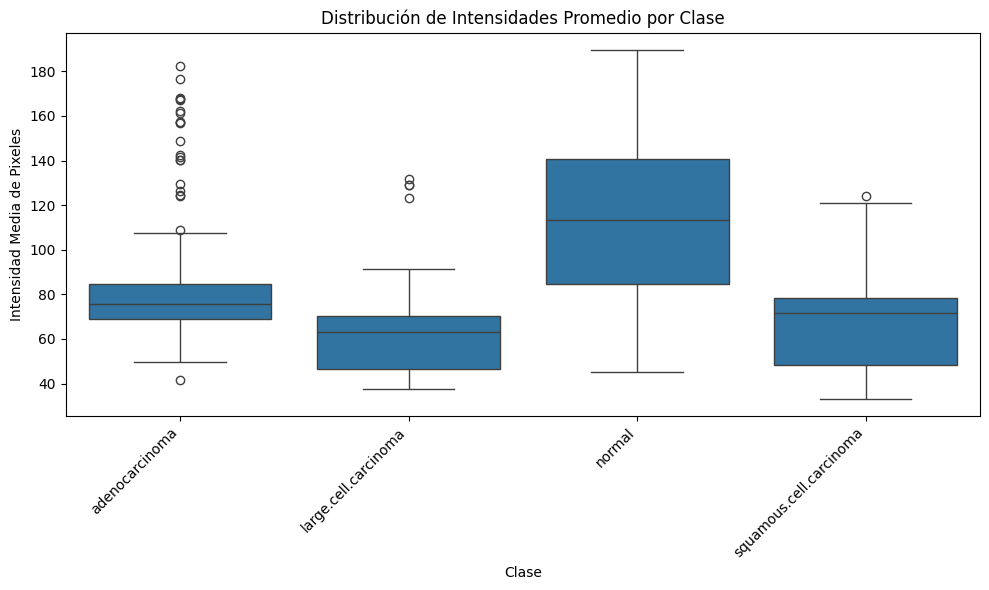

In [50]:
# Filtrar solo algunas clases para graficar (puede haber muchas imágenes por clase)
selected_classes = intensity_df['class'].unique()

# Crear histograma de intensidades promedio por clase
plt.figure(figsize=(10, 6))
sns.boxplot(data=intensity_df, x="class", y="mean")
plt.title("Distribución de Intensidades Promedio por Clase")
plt.ylabel("Intensidad Media de Pixeles")
plt.xlabel("Clase")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Análisis del Boxplot: Intensidad Media por Clase

El gráfico de cajas muestra la distribución de la **intensidad promedio de píxeles** por clase en el conjunto de entrenamiento:

- **Normal**: Tiene las intensidades más altas (mediana > 110), con una amplia dispersión y varios valores atípicos por encima de 180. Esto indica una mayor luminosidad general en pulmones sanos.
- **Adenocarcinoma** y **Squamous cell carcinoma**: Presentan medianas entre 70 y 80, con distribución más compacta. Reflejan menor brillo debido a la presencia de masas o lesiones.
- **Large cell carcinoma**: Es la clase con menor intensidad media (mediana < 70), lo que podría asociarse a imágenes más oscuras o tumores densos.

**Conclusión**: La intensidad promedio puede ser un buen descriptor para distinguir entre imágenes normales y patológicas, aunque entre subtipos de cáncer hay solapamientos.

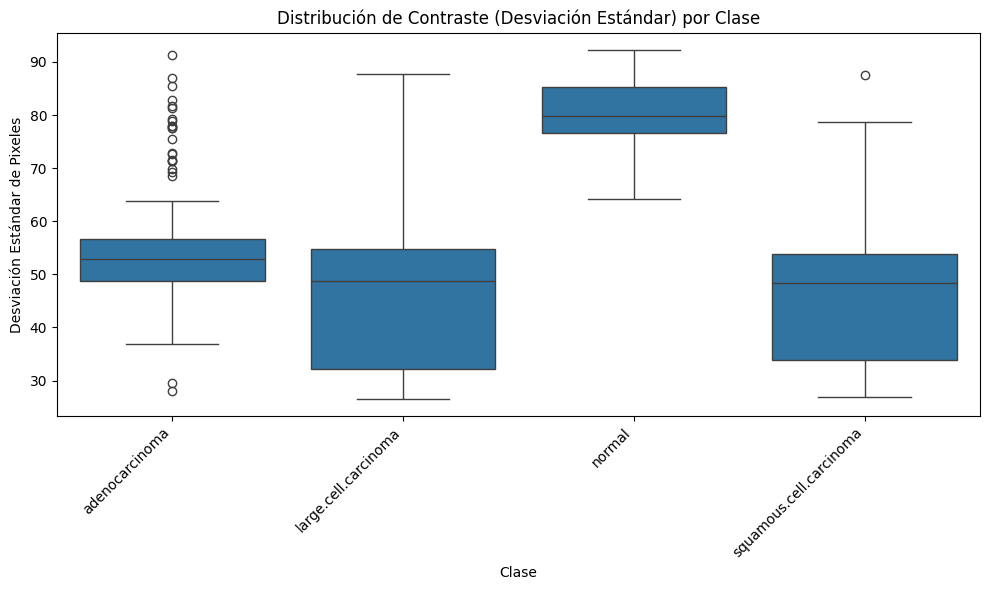

In [51]:
# Histograma de la desviación estándar por clase
plt.figure(figsize=(10, 6))
sns.boxplot(data=intensity_df, x="class", y="std")
plt.title("Distribución de Contraste (Desviación Estándar) por Clase")
plt.ylabel("Desviación Estándar de Pixeles")
plt.xlabel("Clase")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Análisis: Desviación Estándar por Clase (Contraste)

Este gráfico muestra la variabilidad en la intensidad de píxeles, lo que se traduce en el **contraste** de las imágenes:

- **Normal**: Presenta la mayor dispersión de valores (`std ≈ 75–90`), lo que indica imágenes más ricas en variaciones de gris. Esto es consistente con pulmones sanos que contienen más detalles estructurales visibles.
- **Clases patológicas** (adenocarcinoma, large cell, squamous cell): Tienen menor contraste, con medianas entre `50–55`, lo que puede deberse a la homogeneidad visual de las lesiones.
- **Large cell carcinoma**: Se destaca por su menor rango de variación (`std ≈ 30–60`), lo que puede indicar lesiones más opacas o compactas.

**Conclusión**: Las imágenes normales tienden a tener mayor contraste, lo cual puede ser útil para diferenciarlas automáticamente de las patológicas.


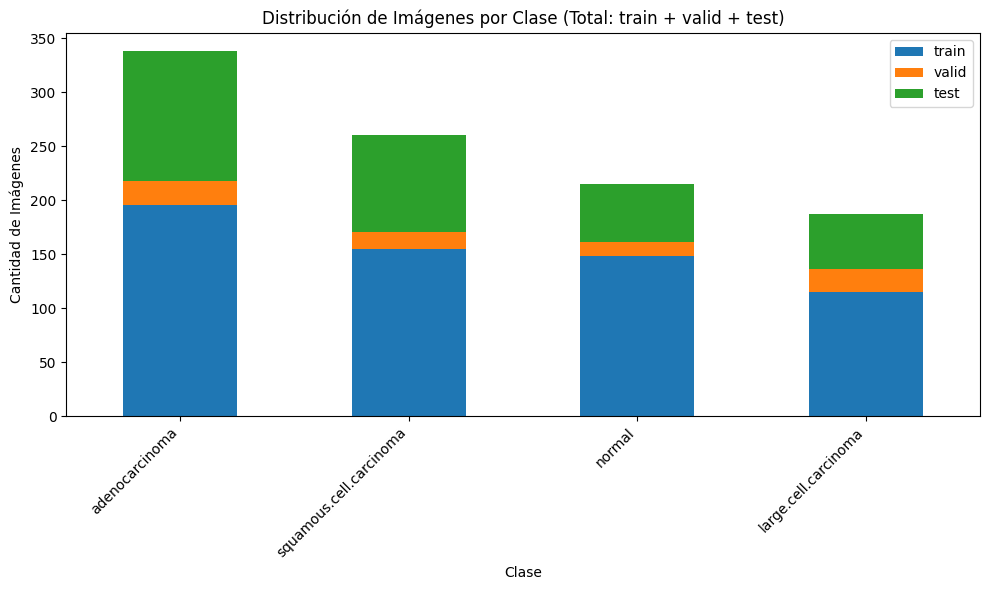

,train,valid,test,total
adenocarcinoma,195,23,120,338
squamous.cell.carcinoma,155,15,90,260
normal,148,13,54,215
large.cell.carcinoma,115,21,51,187


In [52]:
subsets = ["train", "valid", "test"]
class_distribution = defaultdict(lambda: {"train": 0, "valid": 0, "test": 0})

for subset in subsets:
    subset_path = os.path.join(dataset_root, subset)
    for class_name in os.listdir(subset_path):
        class_path = os.path.join(subset_path, class_name)
        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
            class_distribution[class_name][subset] = count

# Convertir a DataFrame
df_balance = pd.DataFrame(class_distribution).T.fillna(0).astype(int)
df_balance["total"] = df_balance.sum(axis=1)
df_balance = df_balance.sort_values("total", ascending=False)

# Graficar
df_balance[["train", "valid", "test"]].plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Distribución de Imágenes por Clase (Total: train + valid + test)")
plt.xlabel("Clase")
plt.ylabel("Cantidad de Imágenes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Mostrar tabla
df_balance

### Análisis de Balance de Clases (Train + Valid + Test)

- **Las clases están desbalanceadas** en cuanto al número total de imágenes:
  - **Adenocarcinoma** (`218`) y **Normal** (`215`) están ligeramente por encima.
  - **Squamous cell carcinoma** (`170`) y **Large cell carcinoma** (`136`) tienen menor representación.
  - En el conjunto `test`, las clases están etiquetadas de forma genérica (sin detalles TNM), y no se solapan con las usadas en `train`/`valid`.

- Las clases de `test` (`adenocarcinoma`, `large.cell.carcinoma`, etc.) **no están presentes en `train`**, lo que implica que **el conjunto `test` usa otra nomenclatura**. Esto puede requerir mapear o fusionar nombres si se desea una evaluación conjunta.

#### Conclusión:

El dataset **presenta cierto desbalance**, principalmente entre subtipos de cáncer. Si se entrena un modelo con esta distribución, puede haber un sesgo hacia las clases mayoritarias. Para mitigar este efecto, se recomienda:

- Aplicar técnicas de **data augmentation** para las clases minoritarias.
- Usar **ponderación de clases** durante el entrenamiento.
- Considerar **undersampling** de clases dominantes si la cantidad de datos es muy dispar.

### PREPROCESAMIENTO

In [ ]:
# Paso 1: detectar carpeta raíz del dataset (reutilizamos función anterior)
def find_dataset_root(start_dir="."):
    for root, dirs, _ in os.walk(start_dir):
        if {"train", "test", "valid"}.issubset(set(dirs)):
            return root
    raise FileNotFoundError("No se encontró una carpeta que contenga 'train', 'test' y 'valid'.")

dataset_root = find_dataset_root(".")

# Paso 2: definir transformaciones para cada subconjunto
train_transforms = transforms.Compose([
    transforms.Grayscale(),                      # Convertir a escala de grises
    transforms.Resize((224, 224)),               # Redimensionar
    transforms.RandomHorizontalFlip(),           # Aumento de datos
    transforms.RandomRotation(15),              
    transforms.ToTensor(),                       # Convertir a tensor
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalizar a [-1, 1]
])

val_test_transforms = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Paso 3: cargar datasets con ImageFolder
train_dataset = datasets.ImageFolder(os.path.join(dataset_root, "train"), transform=train_transforms)
valid_dataset = datasets.ImageFolder(os.path.join(dataset_root, "valid"), transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(dataset_root, "test"),  transform=val_test_transforms)

# Paso 4: crear dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

# Paso 5: mostrar las clases detectadas
print("Clases detectadas:", train_dataset.classes)

## Se aplica data augmentation sola a las clases desbalanceadas

In [ ]:
# Transformaciones fuertes para clases minoritarias
strong_augmentation = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Transformación básica para clases balanceadas
basic_augmentation = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Definir las clases minoritarias
minority_classes = [
    "large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa",
    "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa"
]

# Custom Dataset para aplicar distintas transformaciones según clase
class CustomAugmentedDataset(ImageFolder):
    def __init__(self, root, transform_dict):
        super().__init__(root, transform=None)  # override default
        self.transform_dict = transform_dict
        self.class_to_idx = self.class_to_idx  # name → int

    def __getitem__(self, index):
        path, target = self.samples[index]
        image = Image.open(path).convert("L")
        class_name = self.classes[target]

        transform = self.transform_dict.get(class_name, basic_augmentation)
        image = transform(image)

        return image, target

# Crear el diccionario de transformaciones específicas
transform_dict = {cls: strong_augmentation for cls in minority_classes}

# Ruta del conjunto de entrenamiento
train_dir = os.path.join(dataset_root, "train")

# Dataset y dataloader
train_dataset = CustomAugmentedDataset(train_dir, transform_dict)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)

train_dataset
train_loader 